In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [70]:
df = pd.read_csv('nonlinear_moons_dataset.csv')

In [71]:
df.head()

,Feature1,Feature2,Label
0,0.830948,-0.296546,1
1,1.088387,0.899693,0
2,1.135634,-0.462935,1
3,-0.082277,1.059718,0
4,0.443047,1.418977,0


In [72]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

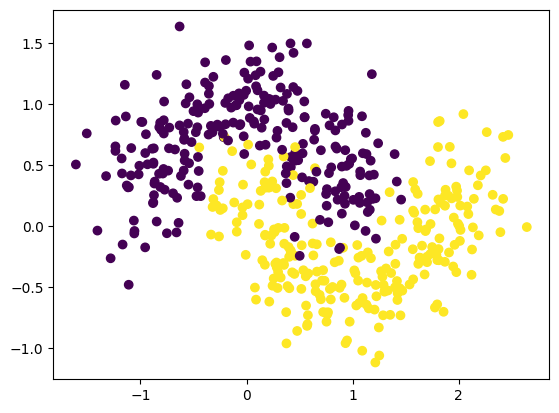

In [73]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [74]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

In [75]:
clf.fit(X, y)

LogisticRegression()

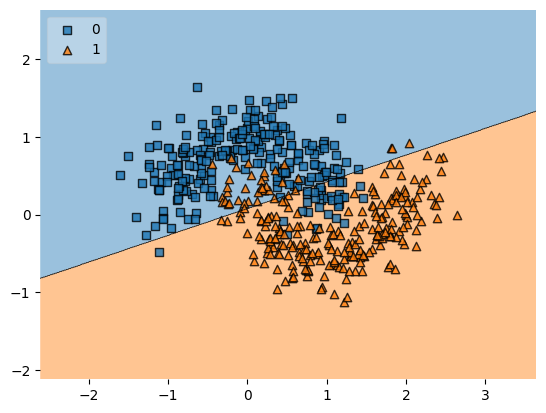

In [76]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X,y.astype('int'), clf, legend=2)
plt.show()

In [77]:
from sklearn.model_selection import cross_val_score

np.mean(cross_val_score(clf, X, y, scoring='accuracy', cv=10))

np.float64(0.8459999999999999)

In [78]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)
X_trf = poly.fit_transform(X)

In [79]:
clf_trf = LogisticRegression()

np.mean(cross_val_score(clf_trf, X_trf, y, scoring='accuracy', cv=10))

np.float64(0.938)

In [80]:
def plot_decision_boundary(X,y,degree=1):

    poly = PolynomialFeatures(degree=degree)
    X_trf = poly.fit_transform(X)

    clf = LogisticRegression()
    clf.fit(X_trf, y)

    accuracy = np.mean(cross_val_score(clf, X_trf, y, scoring='accuracy', cv=10))

    a = np.arange(start=X[:,0].min()-1, stop=X[:,0].max()+1, step=0.01)
    b = np.arange(start=X[:,1].min()-1, stop=X[:,1].max()+1, step=0.01)

    XX, YY = np.meshgrid(a,b)

    input_array = np.array([XX.ravel(), YY.ravel()]).T

    labels = clf.predict(poly.transform(input_array))

    plt.contourf(XX, YY, labels.reshape(XX.shape), alpha=0.5)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.title("Degree = {}, accuracy is {}".format(degree, np.round(accuracy, 4)))

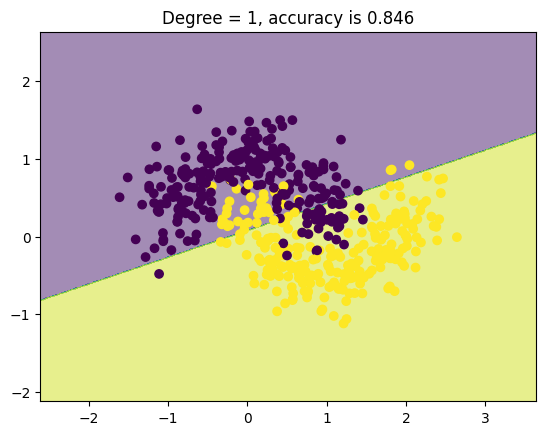

In [81]:
plot_decision_boundary(X,y)

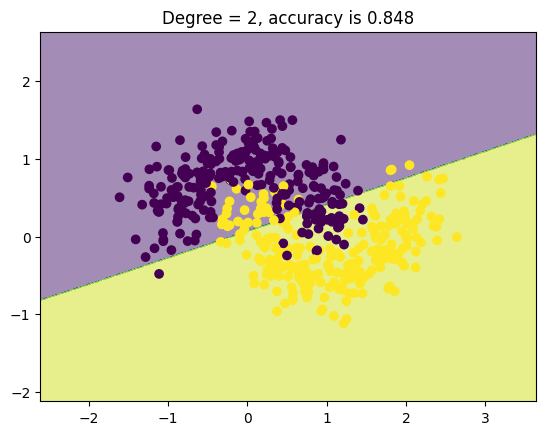

In [82]:
plot_decision_boundary(X,y, degree=2)

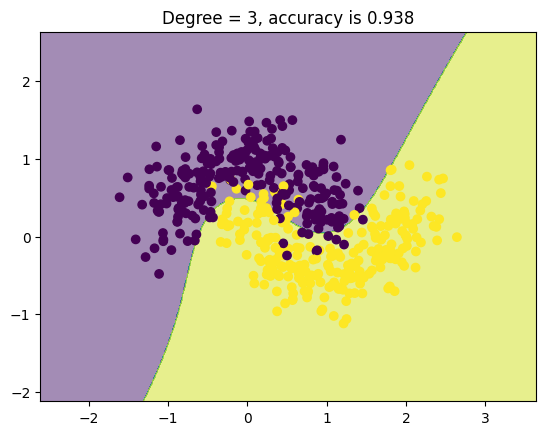

In [83]:
plot_decision_boundary(X, y, degree=3)

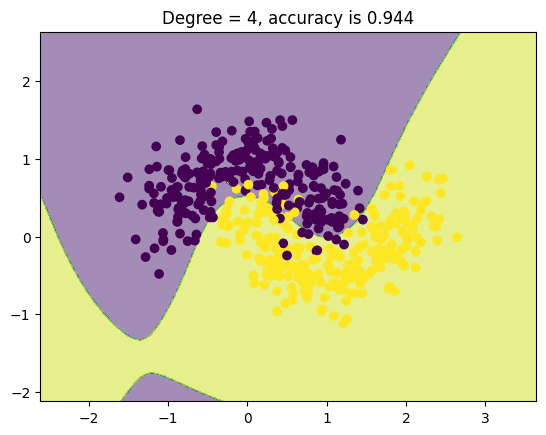

In [84]:
plot_decision_boundary(X, y, degree=4)

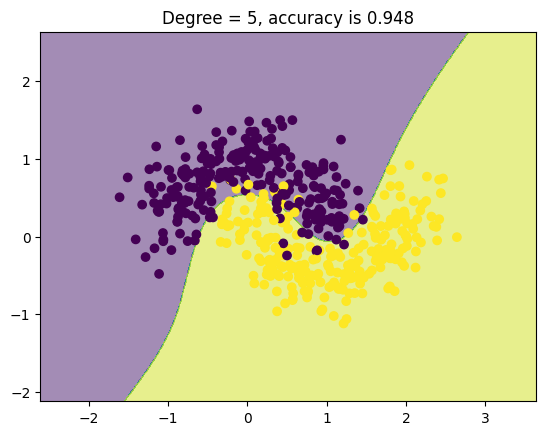

In [85]:
plot_decision_boundary(X, y, degree=5)

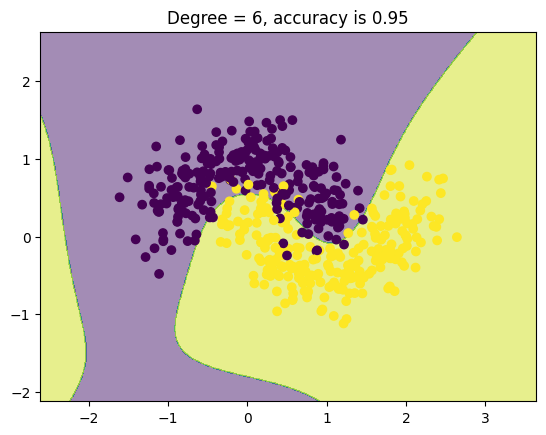

In [86]:
plot_decision_boundary(X, y, degree=6)